<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>10 $\rightarrow$ LangGraph Chatbot</b>     
  <span style="color:#ffb5a7;">(Stateful AI Agents in LangGraph)</span>
</div>

In [2]:
from typing import TypedDict, Annotated


from langgraph.graph import StateGraph, START, END 
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #065f46, #854d0e);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. State Management & Reducer Functions
</span>

- **`ChatState(TypedDict)`**
    - In LangGraph, every workflow needs a state to pass data between nodes. 
    - For a chatbot, the most crucial data is the conversation history. 
    - This class defines the state as a dictionary containing a list of `messages`.

* **`add_messages` (The Reducer)**: By default, when a new value is passed to a LangGraph state, it **overwrites** the previous value. If the user asked a new question, the old conversation would be deleted. To prevent this, a "reducer" function is needed. While you could use a basic append operator (`operator.add`), `add_messages` is a specialized, optimized built-in LangGraph function specifically designed for handling and appending `BaseMessage` objects (Human, AI, System, Tool messages).

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #065f46, #854d0e);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">
  2. The Chat Node
</span>

- **`chat_node(state: ChatState)`**: This is the only node in this simple sequential graph. Its job is to extract the current list of messages from the state, pass them to the LLM, and return the newly generated AI response.


- **`ChatOpenAI()`**: This initializes the default OpenAI Large Language Model. It acts as the brain of the chatbot, receiving the `messages` list and generating an appropriate `AIMessage` in return.


- **`return {"messages": [response]}`**: Because the `add_messages` reducer is active in the state, returning the new AI response in a list does not overwrite the history; it simply appends the new message to the existing list of messages.

In [ ]:
# Initialize the ChatGroq LLM 
llm = ChatGroq(model="llama-3.1-8b-instant")

def chat_node(State: ChatState):
    # Extract the conversation messages from the current state
    messages = State['messages']

    # Send the messages to the language model and get the response
    response = llm.invoke(messages)

    # Return the updated state with the new response appended to the message list
    return ({'messages': [response]})

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #065f46, #854d0e);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">
  3. Graph Construction
</span>

- **`StateGraph(ChatState)`**: This initializes the workflow blueprint and ties it to the specific state structure (`ChatState`) we defined earlier.

-  **`START`** and **`END`**: These dictate the flow of the graph. The user's input triggers the `START`, which routes to the `chat_node`. Once the LLM generates a response, it hits the `END`, terminating that specific execution run.

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #065f46, #854d0e);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">
  4. Persistence (Solving the "Amnesia" Problem)
</span>

- **The Problem:** In the basic `while` loop, every time `chatbot.invoke()` is called, the graph executes from scratch. The LLM forgets previous messages (referred to in the video as the "Ghajini" problem) because the state is erased from memory as soon as the graph reaches the `END` node.

- **`MemorySaver()`**: To fix this, LangGraph uses a concept called **Persistence**. `MemorySaver` is a checkpointer that saves the state of the graph into the computer's RAM *after* the workflow ends. When the next message comes in, instead of starting from zero, the graph fetches the previous state from RAM and appends the new message to it. 

    > Note: For production, a database checkpointer is recommended instead of RAM so data isn't lost when the program closes

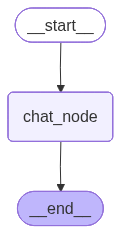

In [6]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #065f46, #854d0e);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">
  5. Threading and Configuration
</span>

- **`config = {"configurable": {"thread_id": "1"}}`**: When you introduce memory, the chatbot needs a way to distinguish between different users or different conversations (e.g., Nitish chatting vs. Rahul chatting). A "thread" represents one distinct interaction session. By passing a `thread_id` inside the config during `.invoke()`, you tell the `MemorySaver` exactly which conversation history to retrieve and update.

In [ ]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('🗨️User: ', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('🤖AI: ', response['messages'][-1].content)